# Thyroid Disease Detection - End-to-End Machine Learning Pipeline

## 1. Problem Statement

### 1.1 Business Context

Thyroid disease is one of the most prevalent endocrine disorders worldwide. The thyroid gland produces hormones that regulate metabolism, energy generation, and the overall chemical balance of the body. Abnormalities in thyroid function can lead to conditions such as hypothyroidism (underactive thyroid) and compensated hypothyroidism, which, if left undiagnosed, can result in serious health complications including cardiovascular disease, infertility, and neurological impairment.

Traditional diagnostic workflows involve manual interpretation of blood test results by endocrinologists. This process is time-consuming, subject to inter-observer variability, and becomes a bottleneck in high-volume clinical settings. An automated, data-driven classification system can serve as a reliable screening tool to flag potential thyroid disorders early, thereby reducing diagnostic turnaround time and enabling timely intervention.

### 1.2 Objective

The objective of this project is to build a robust machine learning classification pipeline that can accurately predict whether a patient has a thyroid disorder based on clinical and demographic attributes. Specifically, the model will classify patients into one of the following categories:

- **Negative** -- No thyroid disorder detected.
- **Compensated Hypothyroid** -- A mild form of hypothyroidism where TSH is elevated but thyroid hormone levels remain within normal range.
- **Primary Hypothyroid** -- A condition where the thyroid gland fails to produce adequate hormones, resulting in elevated TSH and low T4 levels.

### 1.3 Approach

This notebook implements the complete machine learning lifecycle:

1. Data loading and initial exploration.
2. Exploratory Data Analysis (EDA) covering distributions, correlations, and missing value patterns.
3. Data preprocessing including handling invalid entries, encoding categorical features, missing value imputation, and class imbalance treatment.
4. Clustering-based model training using KMeans to segment data before fitting separate classifiers per cluster.
5. Model selection using hyperparameter-tuned Random Forest and KNN classifiers evaluated via ROC-AUC.
6. Summary of results and conclusions.

### 1.4 Dataset

The dataset used is the **hypothyroid.csv** file containing 3772 patient records with 30 attributes including demographic information (age, sex), binary medical history flags (on_thyroxine, thyroid_surgery, etc.), measured lab values (TSH, T3, TT4, T4U, FTI, TBG), and the target class label.

## 2. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report,
    confusion_matrix, f1_score
)
from imblearn.over_sampling import RandomOverSampler
from kneed import KneeLocator
from collections import Counter

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Data Loading

In [2]:
# Load the dataset
df = pd.read_csv("hypothyroid.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3772, 30)


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH_measured,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,Class
0,41,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,1.3,t,2.5,t,125,t,1.14,t,109,f,?,SVHC,negative
1,23,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,4.1,t,2,t,102,f,?,f,?,f,?,other,negative
2,46,M,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.98,f,?,t,109,t,0.91,t,120,f,?,other,negative
3,70,F,t,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.16,t,1.9,t,175,f,?,f,?,f,?,other,negative
4,70,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.72,t,1.2,t,61,t,0.87,t,70,f,?,SVI,negative


In [3]:
df.tail()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH_measured,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,Class
3767,30,F,f,f,f,f,f,f,f,f,f,f,f,t,f,f,f,?,f,?,f,?,f,?,f,?,f,?,other,negative
3768,68,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,1,t,2.1,t,124,t,1.08,t,114,f,?,SVI,negative
3769,74,F,f,f,f,f,f,f,f,f,t,f,f,f,f,f,t,5.1,t,1.8,t,112,t,1.07,t,105,f,?,other,negative
3770,72,M,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.7,t,2,t,82,t,0.94,t,87,f,?,SVI,negative
3771,64,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,1,t,2.2,t,99,t,1.07,t,92,f,?,other,negative


## 4. Initial Data Inspection

In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   age                        3772 non-null   str  
 1   sex                        3772 non-null   str  
 2   on_thyroxine               3772 non-null   str  
 3   query_on_thyroxine         3772 non-null   str  
 4   on_antithyroid_medication  3772 non-null   str  
 5   sick                       3772 non-null   str  
 6   pregnant                   3772 non-null   str  
 7   thyroid_surgery            3772 non-null   str  
 8   I131_treatment             3772 non-null   str  
 9   query_hypothyroid          3772 non-null   str  
 10  query_hyperthyroid         3772 non-null   str  
 11  lithium                    3772 non-null   str  
 12  goitre                     3772 non-null   str  
 13  tumor                      3772 non-null   str  
 14  hypopituitary              3772 non

In [5]:
# Statistical summary for all columns
df.describe(include='all')

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH_measured,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,Class
count,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772
unique,94,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,288,2,70,2,242,2,147,2,235,1,1,5,4
top,59,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,?,t,?,t,?,t,?,t,?,f,?,other,negative
freq,95,2480,3308,3722,3729,3625,3719,3719,3713,3538,3535,3754,3738,3676,3771,3588,3403,369,3003,769,3541,231,3385,387,3387,385,3772,3772,2201,3481


In [6]:
# Check the unique values in each column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()[:10]}")
    print()

age: 94 unique values -> <StringArray>
['41', '23', '46', '70', '18', '59', '80', '66', '68', '84']
Length: 10, dtype: str

sex: 3 unique values -> <StringArray>
['F', 'M', '?']
Length: 3, dtype: str

on_thyroxine: 2 unique values -> <StringArray>
['f', 't']
Length: 2, dtype: str

query_on_thyroxine: 2 unique values -> <StringArray>
['f', 't']
Length: 2, dtype: str

on_antithyroid_medication: 2 unique values -> <StringArray>
['f', 't']
Length: 2, dtype: str

sick: 2 unique values -> <StringArray>
['f', 't']
Length: 2, dtype: str

pregnant: 2 unique values -> <StringArray>
['f', 't']
Length: 2, dtype: str

thyroid_surgery: 2 unique values -> <StringArray>
['f', 't']
Length: 2, dtype: str

I131_treatment: 2 unique values -> <StringArray>
['f', 't']
Length: 2, dtype: str

query_hypothyroid: 2 unique values -> <StringArray>
['f', 't']
Length: 2, dtype: str

query_hyperthyroid: 2 unique values -> <StringArray>
['f', 't']
Length: 2, dtype: str

lithium: 2 unique values -> <StringArray>
['f',

In [7]:
# Check the shape and duplicate rows
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())

Number of rows: 3772
Number of columns: 30
Duplicate rows: 61


## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Variable Distribution

Target class distribution:
Class
negative                   3481
compensated_hypothyroid     194
primary_hypothyroid          95
secondary_hypothyroid         2
Name: count, dtype: int64

Target class proportions (%):
Class
negative                   92.29
compensated_hypothyroid     5.14
primary_hypothyroid         2.52
secondary_hypothyroid       0.05
Name: proportion, dtype: float64


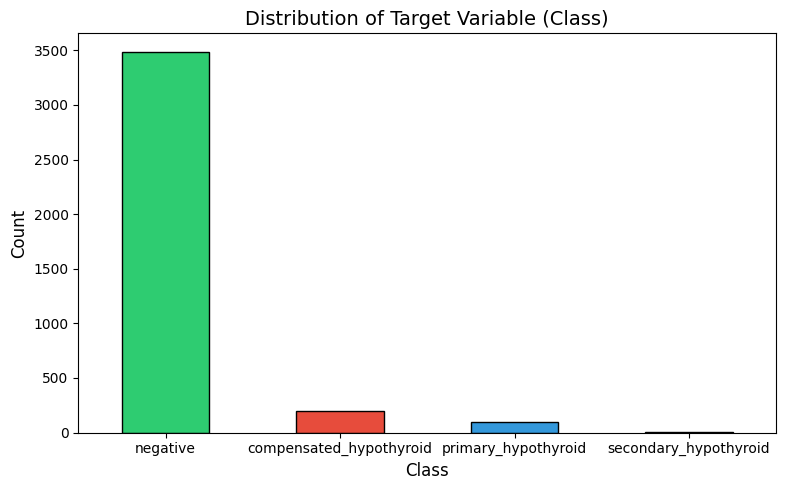

In [8]:
# Target class distribution
print("Target class distribution:")
print(df['Class'].value_counts())
print()
print("Target class proportions (%):")
print(round(df['Class'].value_counts(normalize=True) * 100, 2))

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
df['Class'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black', ax=ax)
ax.set_title('Distribution of Target Variable (Class)', fontsize=14)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The dataset is highly imbalanced. The majority class is "negative" while "compensated_hypothyroid" and "primary_hypothyroid" are minority classes. This imbalance will need to be addressed during preprocessing.

### 5.2 Handling Invalid Entries

Several columns contain '?' as a placeholder for missing values. We need to quantify this before proceeding.

In [9]:
# Count '?' values in each column
question_mark_counts = {}
for col in df.columns:
    count = df[col][df[col] == '?'].count()
    if count > 0:
        question_mark_counts[col] = count

print("Columns with '?' as missing value indicator:")
print("-" * 45)
for col, count in sorted(question_mark_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {col:30s}: {count} ({round(count/len(df)*100, 2)}%)")

Columns with '?' as missing value indicator:
---------------------------------------------
  TBG                           : 3772 (100.0%)
  T3                            : 769 (20.39%)
  T4U                           : 387 (10.26%)
  FTI                           : 385 (10.21%)
  TSH                           : 369 (9.78%)
  TT4                           : 231 (6.12%)
  sex                           : 150 (3.98%)
  age                           : 1 (0.03%)


### 5.3 Identifying Columns to Drop

Based on domain knowledge and EDA findings from the project:

- **Measured columns** (TSH_measured, T3_measured, TT4_measured, T4U_measured, FTI_measured, TBG_measured): These are binary flags indicating whether a lab test was performed. They do not carry diagnostic value themselves.
- **TBG**: Has almost entirely missing values.
- **TSH**: While clinically important, in this dataset it has high missingness and was dropped in the original project pipeline.

These columns will be removed as they were in the original project.

In [10]:
# Columns to drop as per the project pipeline
cols_to_drop = [
    'TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured',
    'FTI_measured', 'TBG_measured', 'TBG', 'TSH'
]

print("Columns before dropping:", df.shape[1])
df_clean = df.drop(columns=cols_to_drop)
print("Columns after dropping:", df_clean.shape[1])
print("Remaining columns:", list(df_clean.columns))

Columns before dropping: 30
Columns after dropping: 22
Remaining columns: ['age', 'sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'T3', 'TT4', 'T4U', 'FTI', 'referral_source', 'Class']


### 5.4 Distribution of Numerical Features

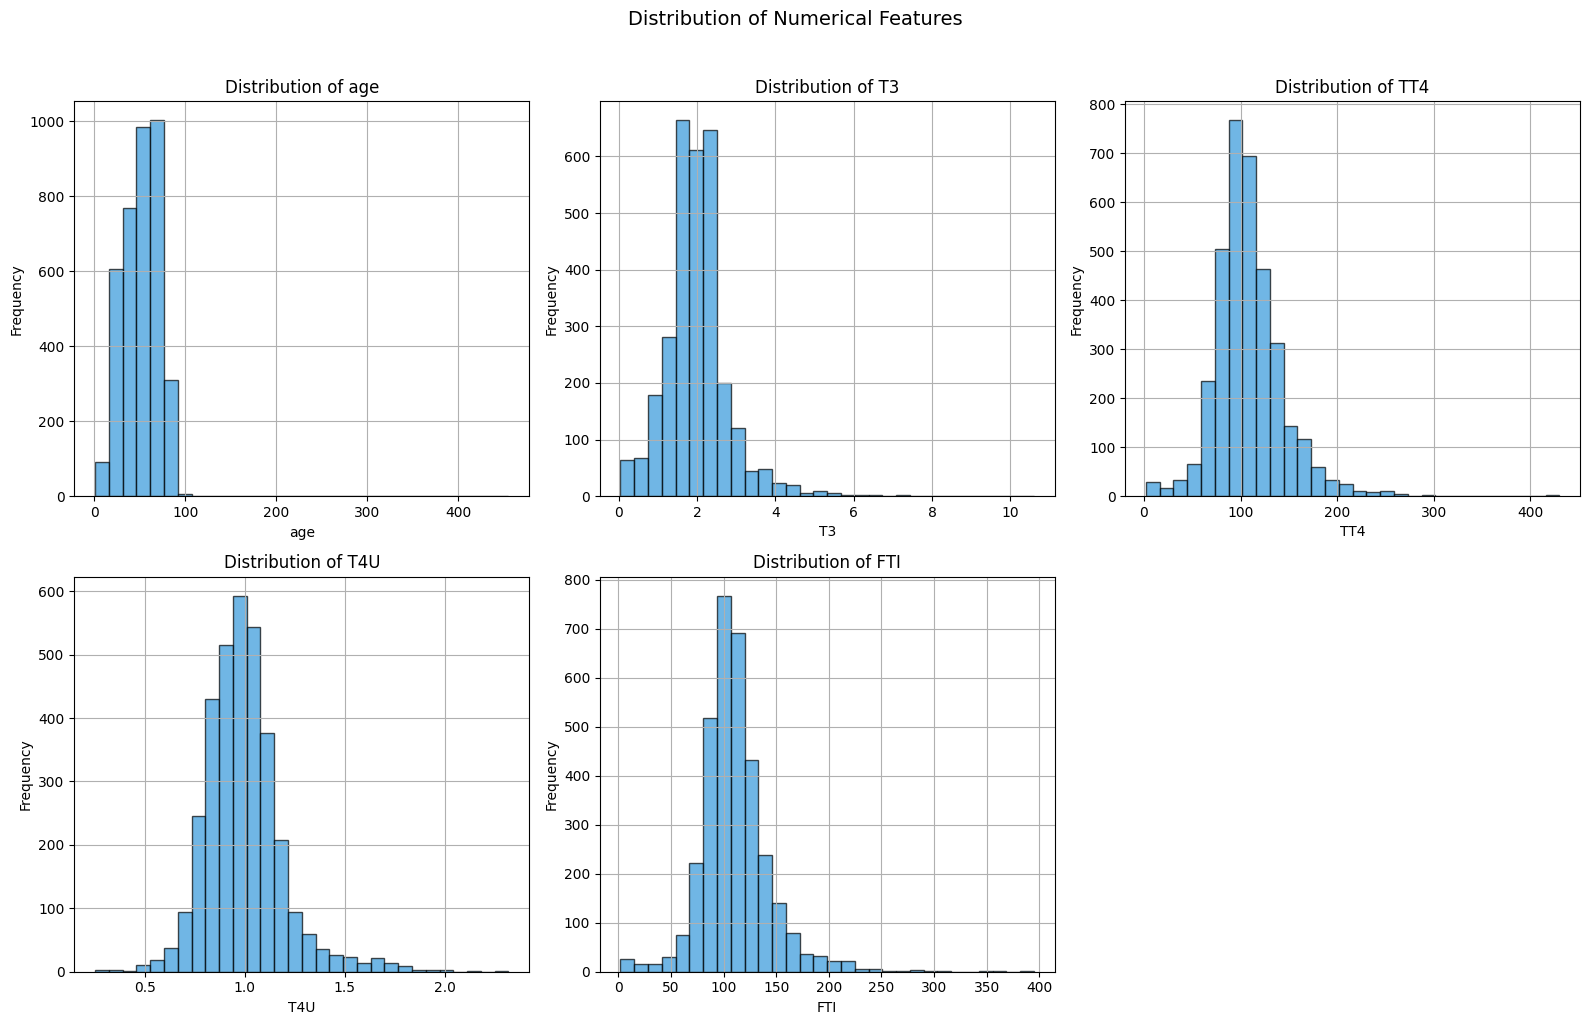

In [11]:
# Replace '?' with NaN for analysis
df_analysis = df_clean.copy()
for col in df_analysis.columns:
    df_analysis[col] = df_analysis[col].replace('?', np.nan)

# Identify numerical columns
numerical_cols = ['age', 'T3', 'TT4', 'T4U', 'FTI']

# Convert numerical columns to float
for col in numerical_cols:
    df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    df_analysis[col].dropna().hist(bins=30, ax=ax, color='#3498db', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontsize=12)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)

# Remove unused subplot
axes[5].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.5 Box Plots for Numerical Features by Target Class

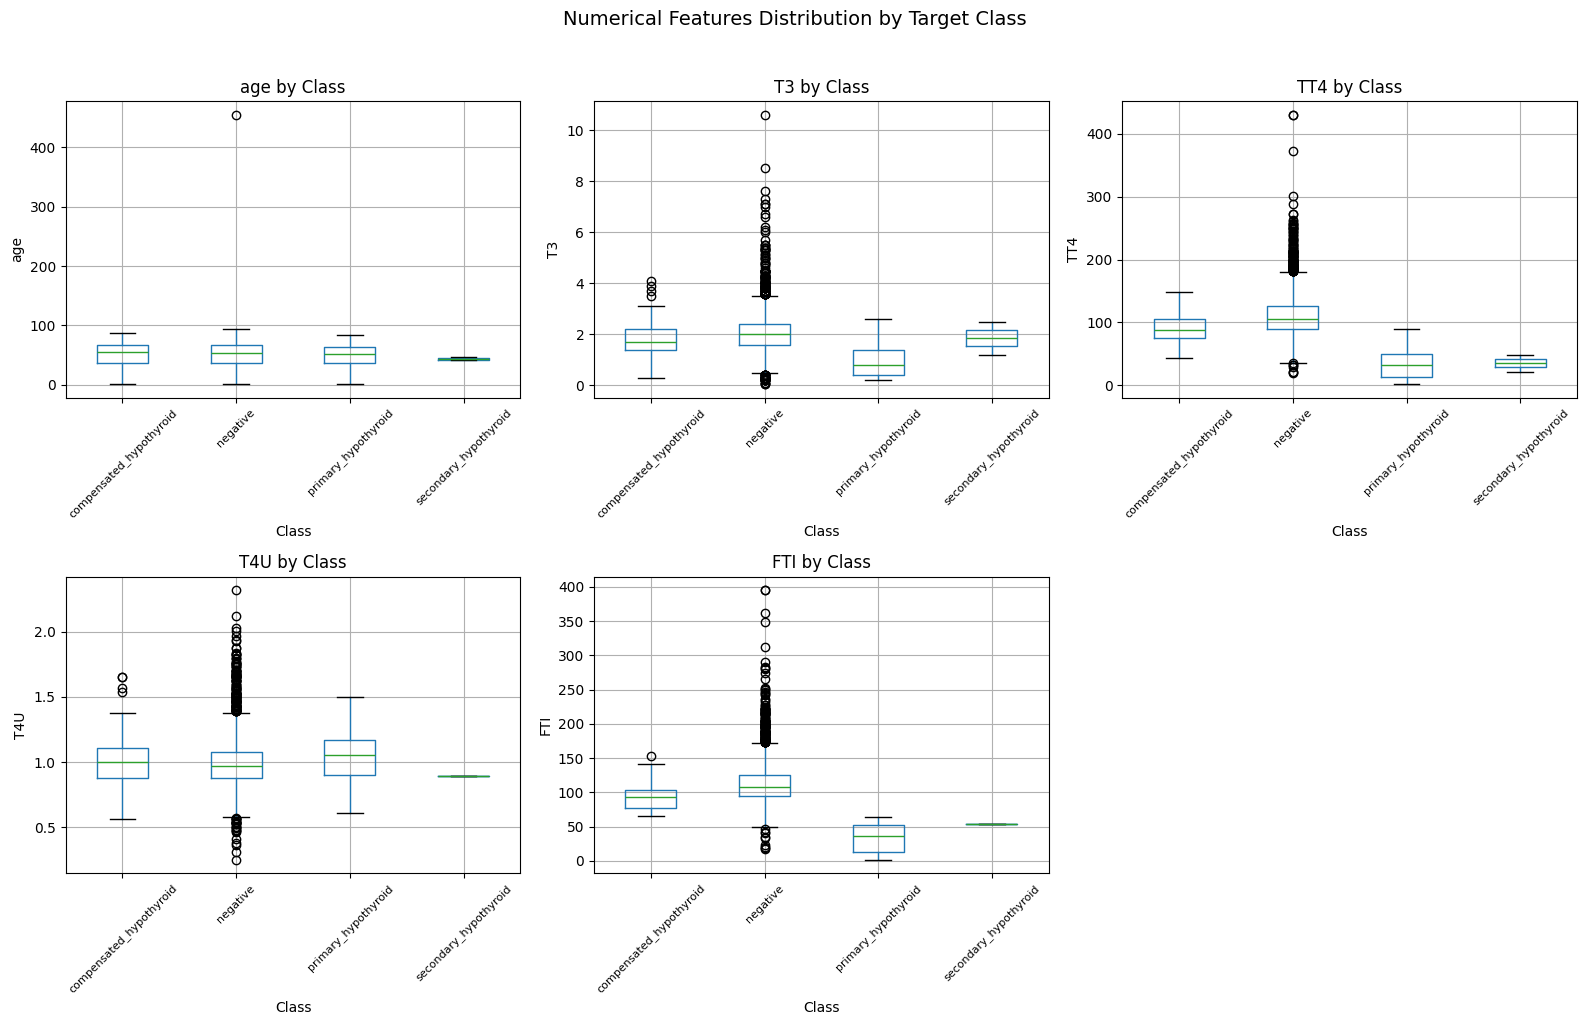

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    data_for_plot = df_analysis[[col, 'Class']].dropna()
    data_for_plot.boxplot(column=col, by='Class', ax=ax)
    ax.set_title(f'{col} by Class', fontsize=12)
    ax.set_xlabel('Class', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    plt.sca(ax)
    plt.xticks(rotation=45, fontsize=8)

axes[5].set_visible(False)

plt.suptitle('Numerical Features Distribution by Target Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.6 Categorical Feature Distribution

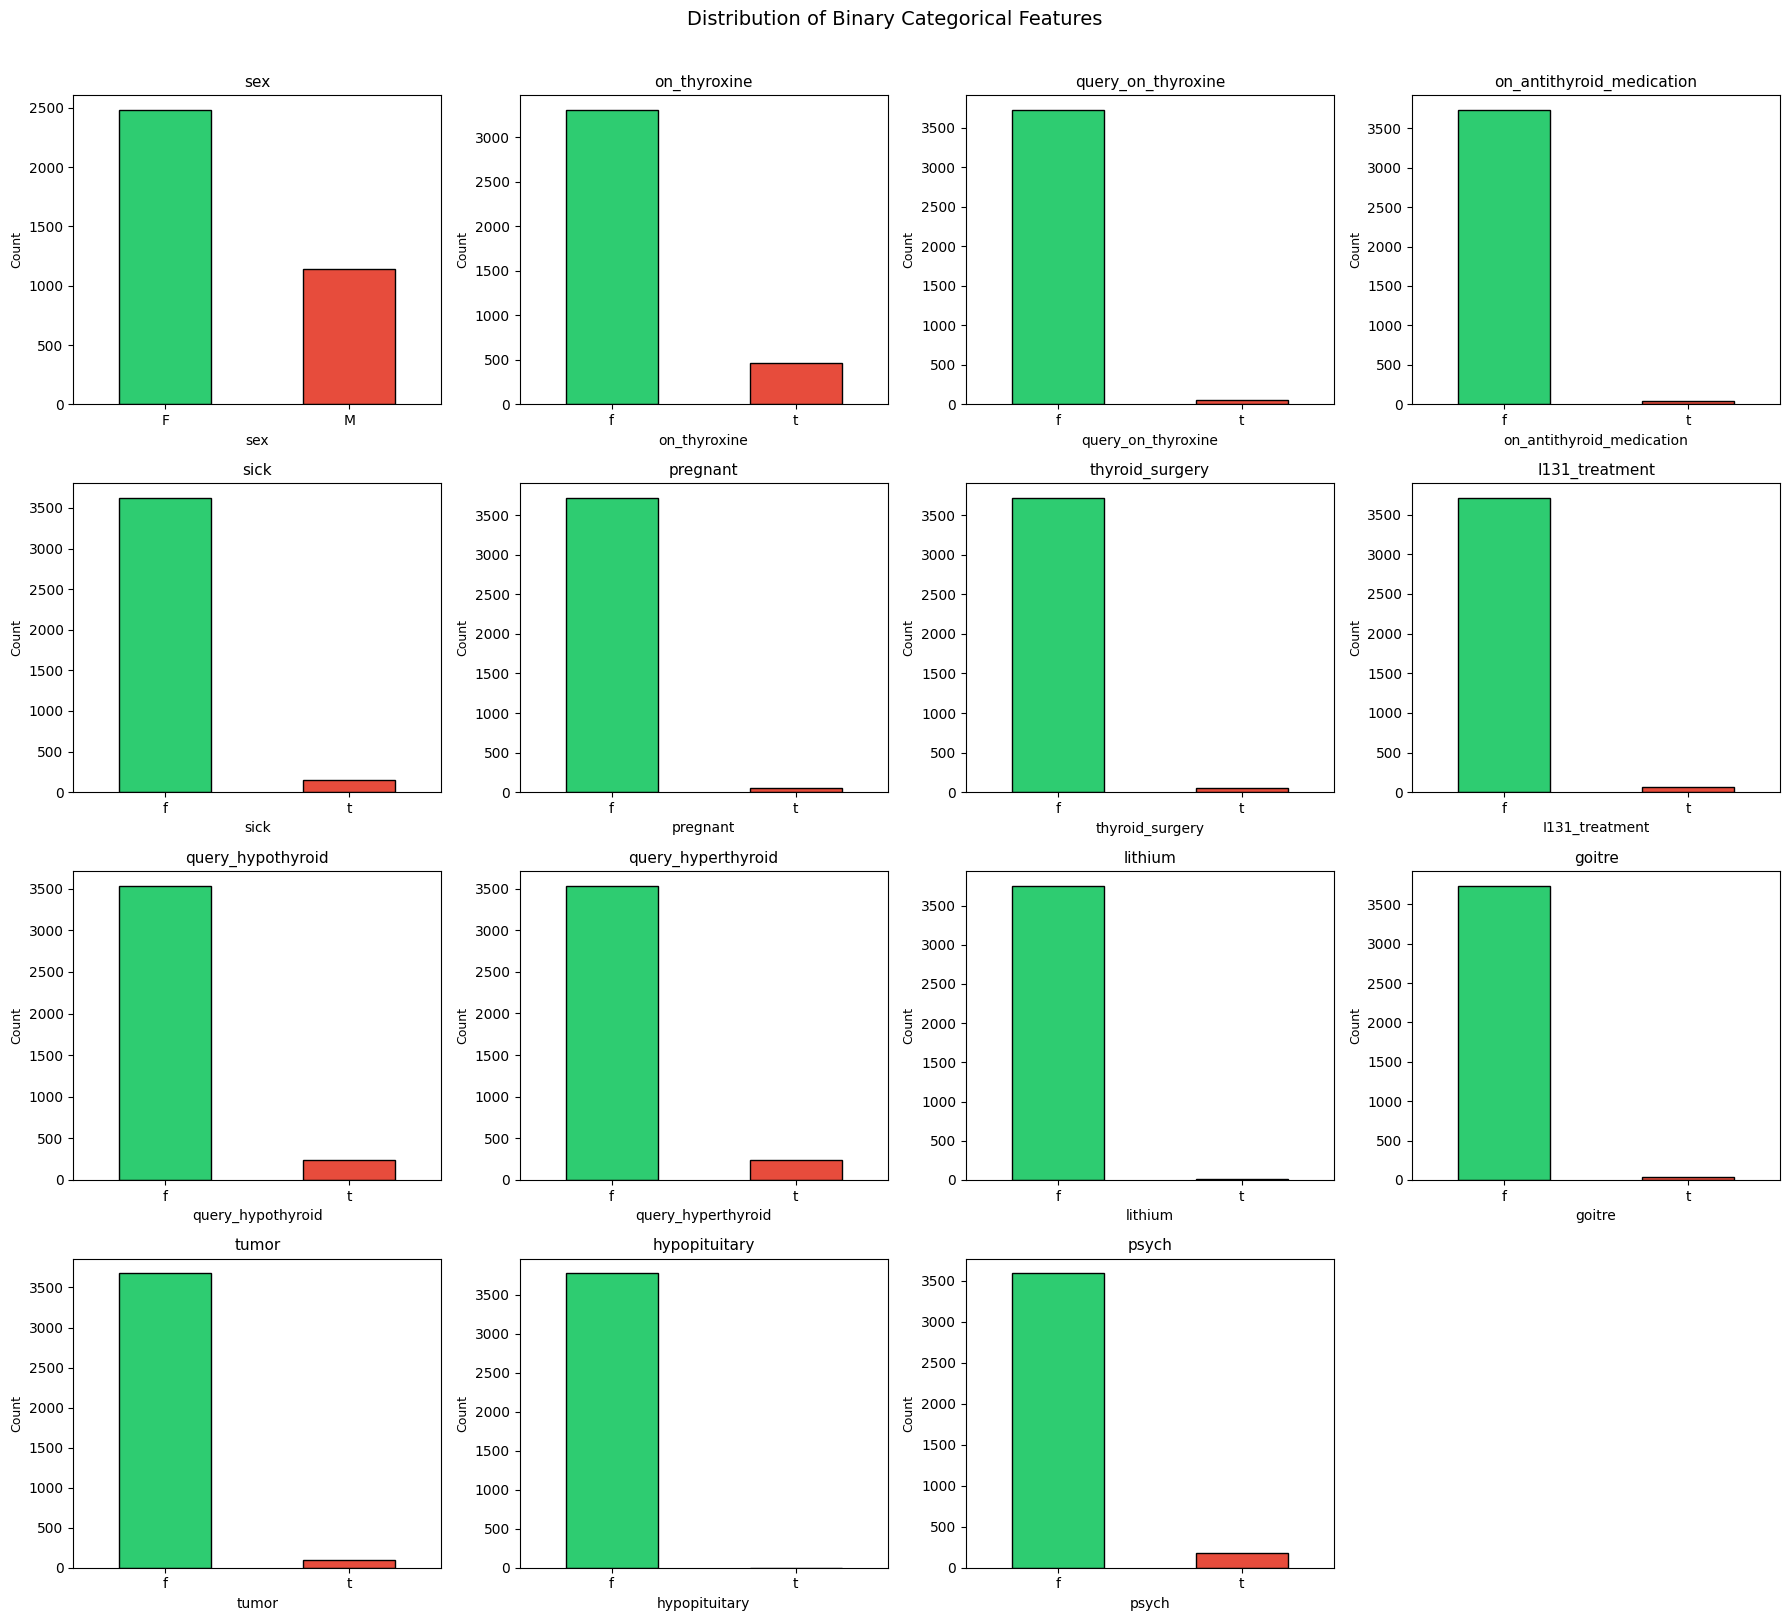

In [13]:
# Identify binary categorical columns (excluding target and referral_source)
binary_cat_cols = [
    'sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication',
    'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
    'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre',
    'tumor', 'hypopituitary', 'psych'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(binary_cat_cols):
    ax = axes[i]
    df_analysis[col].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax.set_title(f'{col}', fontsize=11)
    ax.set_ylabel('Count', fontsize=9)
    ax.tick_params(axis='x', rotation=0)

# Hide unused subplot
axes[15].set_visible(False)

plt.suptitle('Distribution of Binary Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5.7 Referral Source Distribution

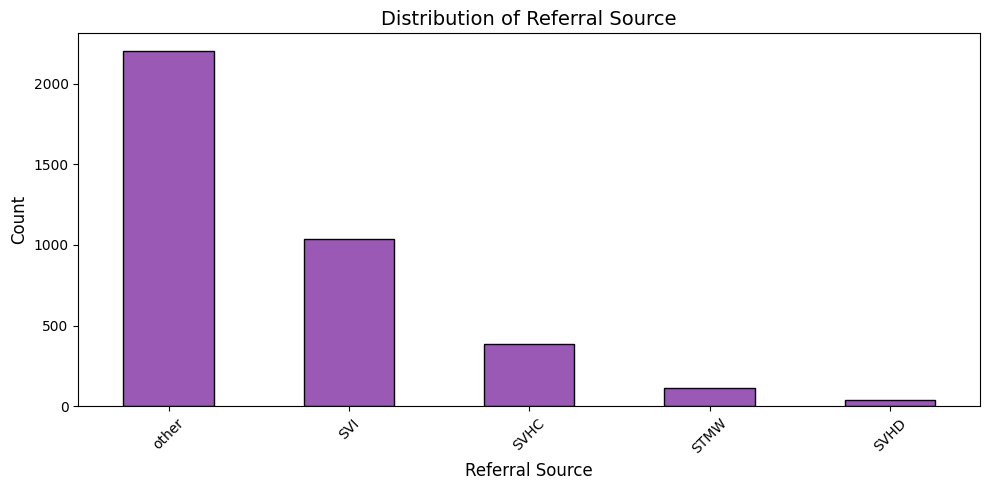

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
df_analysis['referral_source'].value_counts().plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='black')
ax.set_title('Distribution of Referral Source', fontsize=14)
ax.set_xlabel('Referral Source', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.8 Correlation Heatmap of Numerical Features

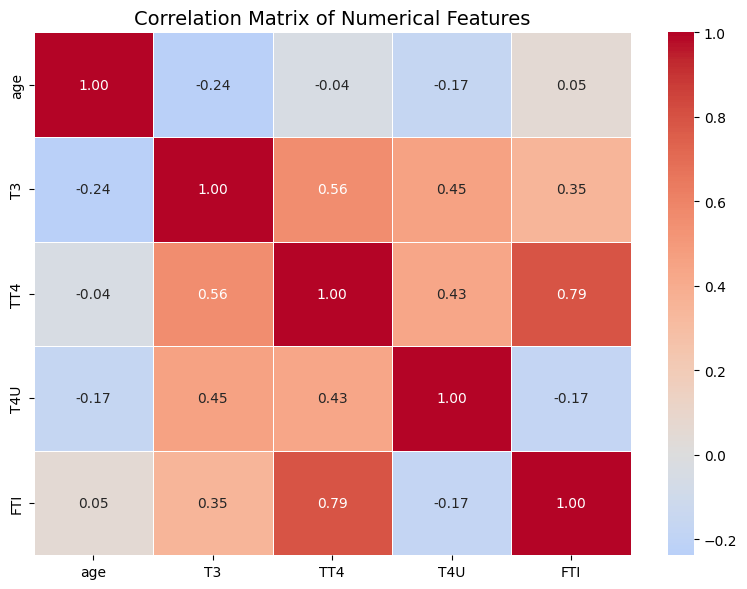

In [15]:
# Correlation matrix for numerical features
corr_df = df_analysis[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

### 5.9 Missing Value Analysis (After Replacing '?' with NaN)

Missing value percentages:
----------------------------------------
  T3                            : 20.39%
  T4U                           : 10.26%
  FTI                           : 10.21%
  TT4                           : 6.12%
  sex                           : 3.98%
  age                           : 0.03%


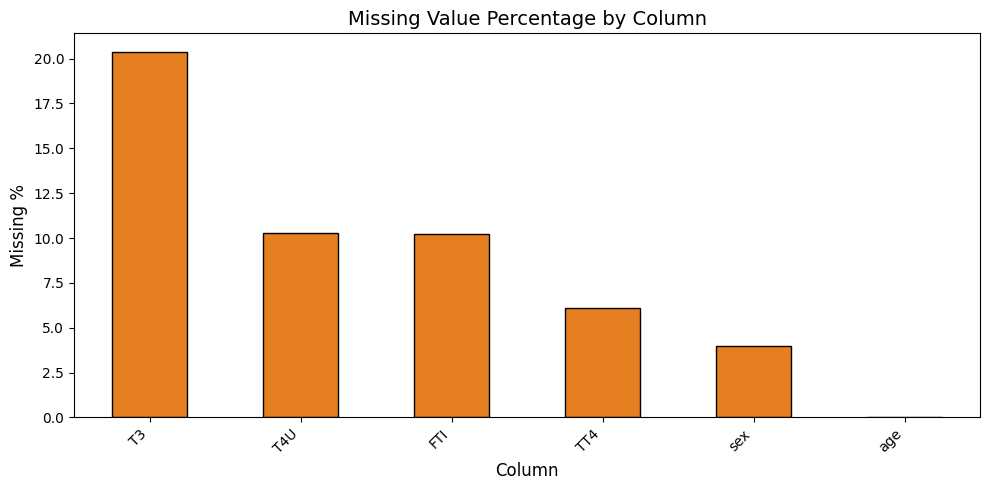

In [16]:
# Missing value percentages
missing_pct = df_analysis.isnull().sum() / len(df_analysis) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print("Missing value percentages:")
print("-" * 40)
for col, pct in missing_pct.items():
    print(f"  {col:30s}: {pct:.2f}%")

if len(missing_pct) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    missing_pct.plot(kind='bar', color='#e67e22', edgecolor='black', ax=ax)
    ax.set_title('Missing Value Percentage by Column', fontsize=14)
    ax.set_xlabel('Column', fontsize=12)
    ax.set_ylabel('Missing %', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### 5.10 Target Class vs Key Features (Cross-tabulation)

In [17]:
# Cross-tabulation of sex vs target class
print("Sex vs Class:")
print(pd.crosstab(df_analysis['sex'], df_analysis['Class'], margins=True))
print()
print("Referral Source vs Class:")
print(pd.crosstab(df_analysis['referral_source'], df_analysis['Class'], margins=True))

Sex vs Class:
Class  compensated_hypothyroid  negative  primary_hypothyroid  \
sex                                                             
F                          145      2265                   69   
M                           42      1077                   22   
All                        187      3342                   91   

Class  secondary_hypothyroid   All  
sex                                 
F                          1  2480  
M                          1  1142  
All                        2  3622  

Referral Source vs Class:
Class            compensated_hypothyroid  negative  primary_hypothyroid  \
referral_source                                                           
STMW                                   4       105                    3   
SVHC                                  10       375                    1   
SVHD                                   3        36                    0   
SVI                                   58       937                   39  

## 6. Data Preprocessing

This section follows the preprocessing pipeline from the project scripts. The steps are:

1. Drop unnecessary columns.
2. Replace '?' with NaN.
3. Encode categorical variables.
4. Separate features and labels.
5. Impute missing values using KNN Imputer.
6. Handle class imbalance using Random Over Sampling.

### 6.1 Reload and Prepare Data

In [18]:
# Reload fresh copy of the data
data = pd.read_csv("hypothyroid.csv")
print("Original shape:", data.shape)

# Step 1: Drop unnecessary columns
cols_to_drop = [
    'TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured',
    'FTI_measured', 'TBG_measured', 'TBG', 'TSH'
]
data = data.drop(columns=cols_to_drop)
print("After dropping measured/TBG/TSH columns:", data.shape)

Original shape: (3772, 30)
After dropping measured/TBG/TSH columns: (3772, 22)


### 6.2 Replace Invalid Values with NaN

In [19]:
# Replace '?' with NaN across all columns
for column in data.columns:
    count = data[column][data[column] == '?'].count()
    if count != 0:
        data[column] = data[column].replace('?', np.nan)

print("Missing values after replacement:")
print(data.isnull().sum()[data.isnull().sum() > 0])

Missing values after replacement:
age      1
sex    150
T3     769
TT4    231
T4U    387
FTI    385
dtype: int64


### 6.3 Encode Categorical Variables

In [20]:
# Encode 'sex' column: F -> 0, M -> 1
data['sex'] = data['sex'].map({'F': 0, 'M': 1})

# For all binary categorical columns with values 'f' and 't', map to 0 and 1
for column in data.columns:
    if column in ['Class', 'referral_source']:
        continue
    unique_vals = set(data[column].dropna().unique())
    if unique_vals == {'f', 't'}:
        data[column] = data[column].map({'f': 0, 't': 1})

# One-hot encode 'referral_source' (use dtype=int for clean numeric columns)
data = pd.get_dummies(data, columns=['referral_source'], dtype=int)

# Encode the target variable
label_encoder = LabelEncoder()
label_encoder.fit(data['Class'])
data['Class'] = label_encoder.transform(data['Class'])

# Convert all columns to numeric (handles any remaining string columns like age, T3, TT4, etc.)
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print("Encoded class mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls} -> {i}")

print()
print("Data shape after encoding:", data.shape)
print("Data types:")
print(data.dtypes.value_counts())
data.head()

Encoded class mapping:
  compensated_hypothyroid -> 0
  negative -> 1
  primary_hypothyroid -> 2
  secondary_hypothyroid -> 3

Data shape after encoding: (3772, 26)
Data types:
int64      20
float64     6
Name: count, dtype: int64


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,T3,TT4,T4U,FTI,Class,referral_source_STMW,referral_source_SVHC,referral_source_SVHD,referral_source_SVI,referral_source_other
0,41.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.5,125.0,1.14,109.0,1,0,1,0,0,0
1,23.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,102.0,NaN,NaN,1,0,0,0,0,1
2,46.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,109.0,0.91,120.0,1,0,0,0,0,1
3,70.0,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1.9,175.0,NaN,NaN,1,0,0,0,0,1
4,70.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.2,61.0,0.87,70.0,1,0,0,0,1,0


### 6.4 Separate Features and Target

In [21]:
X = data.drop(columns=['Class'])
Y = data['Class']

print("Features shape:", X.shape)
print("Target shape:", Y.shape)
print()
print("Target distribution before oversampling:")
print(Y.value_counts())

Features shape: (3772, 25)
Target shape: (3772,)

Target distribution before oversampling:
Class
1    3481
0     194
2      95
3       2
Name: count, dtype: int64


### 6.5 Check and Impute Missing Values

In [22]:
# Check for missing values
null_counts = X.isnull().sum()
null_cols = null_counts[null_counts > 0]

print("Columns with missing values:")
print(null_cols)
print()
print("Total missing values:", X.isnull().sum().sum())

Columns with missing values:
age      1
sex    150
T3     769
TT4    231
T4U    387
FTI    385
dtype: int64

Total missing values: 1923


In [23]:
# Impute missing values using KNN Imputer (k=3, as in the project)
imputer = KNNImputer(n_neighbors=3, weights='uniform', missing_values=np.nan)
X_imputed = imputer.fit_transform(X)

# Round values since KNN Imputer can return float for originally integer columns
X = pd.DataFrame(data=np.round(X_imputed), columns=X.columns)

print("Missing values after imputation:", X.isnull().sum().sum())
print("Features shape:", X.shape)
X.head()

Missing values after imputation: 0
Features shape: (3772, 25)


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,T3,TT4,T4U,FTI,referral_source_STMW,referral_source_SVHC,referral_source_SVHD,referral_source_SVI,referral_source_other
0,41.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,125.0,1.0,109.0,0.0,1.0,0.0,0.0,0.0
1,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,102.0,1.0,99.0,0.0,0.0,0.0,0.0,1.0
2,46.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,109.0,1.0,120.0,0.0,0.0,0.0,0.0,1.0
3,70.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,175.0,1.0,177.0,0.0,0.0,0.0,0.0,1.0
4,70.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,61.0,1.0,70.0,0.0,0.0,0.0,1.0,0.0


### 6.6 Handle Class Imbalance Using Random Over Sampling

In [24]:
print("Class distribution BEFORE oversampling:")
print(Counter(Y))
print()

ros = RandomOverSampler(random_state=42)
X_resampled, Y_resampled = ros.fit_resample(X, Y)

print("Class distribution AFTER oversampling:")
print(Counter(Y_resampled))
print()
print("Resampled features shape:", X_resampled.shape)
print("Resampled target shape:", Y_resampled.shape)

Class distribution BEFORE oversampling:
Counter({1: 3481, 0: 194, 2: 95, 3: 2})

Class distribution AFTER oversampling:
Counter({1: 3481, 0: 3481, 2: 3481, 3: 3481})

Resampled features shape: (13924, 25)
Resampled target shape: (13924,)


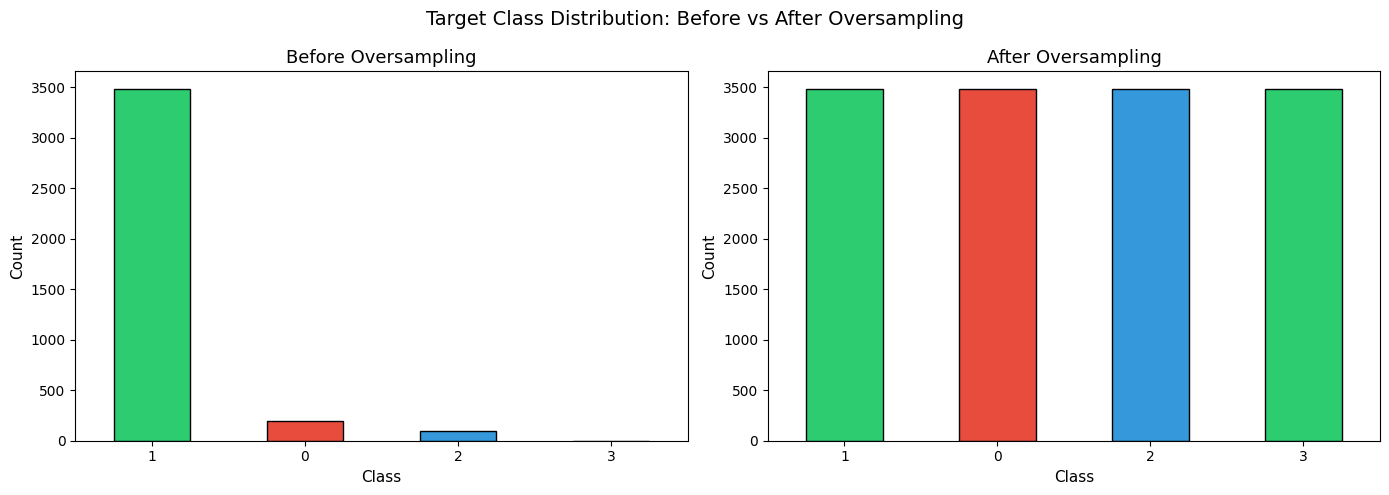

In [25]:
# Visualize class distribution before and after oversampling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(Y).value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black')
axes[0].set_title('Before Oversampling', fontsize=13)
axes[0].set_xlabel('Class', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)

pd.Series(Y_resampled).value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black')
axes[1].set_title('After Oversampling', fontsize=13)
axes[1].set_xlabel('Class', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Target Class Distribution: Before vs After Oversampling', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Clustering Using KMeans

The project uses a clustering-based approach where the data is first segmented into clusters using KMeans, and then a separate classifier is trained for each cluster. This can improve performance when the data has heterogeneous subgroups.

### 7.1 Elbow Method to Determine Optimal Number of Clusters

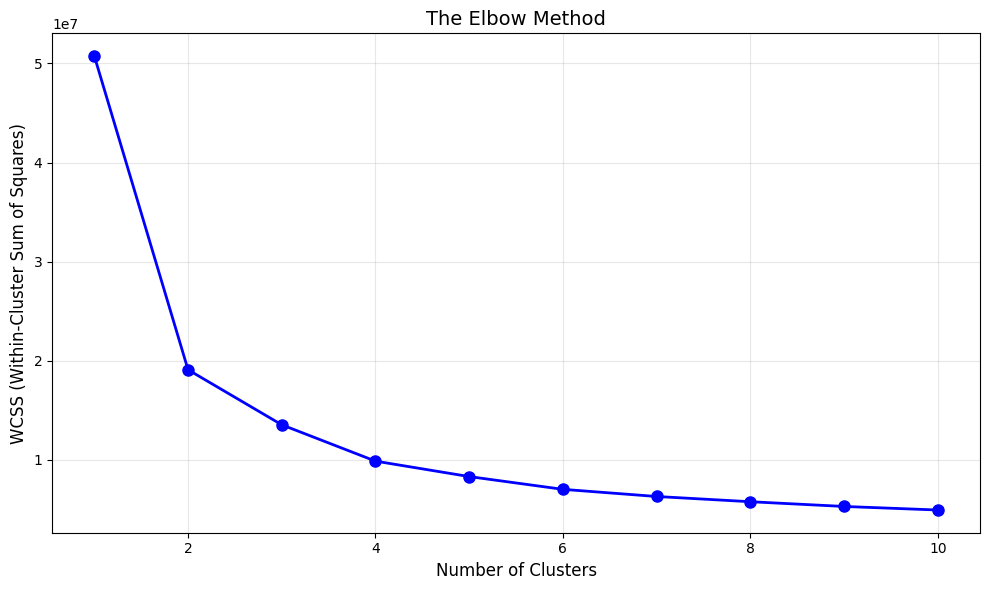

Optimal number of clusters (via Knee/Elbow): 3


In [26]:
# Elbow method to find optimal number of clusters
wcss = []
K_range = range(1, 11)

for i in K_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_resampled)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
ax.set_title('The Elbow Method', fontsize=14)
ax.set_xlabel('Number of Clusters', fontsize=12)
ax.set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find the optimal number of clusters using KneeLocator
kn = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
optimal_clusters = kn.knee
print(f"Optimal number of clusters (via Knee/Elbow): {optimal_clusters}")

### 7.2 Create Clusters

In [27]:
# Fit KMeans with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_resampled)

# Add cluster labels to the data
X_clustered = X_resampled.copy()
X_clustered['Cluster'] = cluster_labels
X_clustered['Labels'] = Y_resampled.values

print("Cluster distribution:")
print(X_clustered['Cluster'].value_counts().sort_index())
print()

# Check class distribution within each cluster
for cluster_id in sorted(X_clustered['Cluster'].unique()):
    cluster_subset = X_clustered[X_clustered['Cluster'] == cluster_id]
    print(f"Cluster {cluster_id} (n={len(cluster_subset)}):")
    print(f"  Class distribution: {dict(cluster_subset['Labels'].value_counts())}")

Cluster distribution:
Cluster
0    3504
1    5142
2    5278
Name: count, dtype: int64

Cluster 0 (n=3504):
  Class distribution: {2: np.int64(1763), 3: np.int64(1733), 1: np.int64(8)}
Cluster 1 (n=5142):
  Class distribution: {1: np.int64(3000), 0: np.int64(2026), 2: np.int64(116)}
Cluster 2 (n=5278):
  Class distribution: {3: np.int64(1748), 2: np.int64(1602), 0: np.int64(1455), 1: np.int64(473)}


## 8. Model Training

For each cluster, we train two models -- Random Forest and KNN -- with hyperparameter tuning using GridSearchCV. The model with the better ROC-AUC score is selected as the best model for that cluster.

### 8.1 Define Hyperparameter Tuning Functions

In [28]:
def get_best_random_forest(train_x, train_y):
    """
    Perform GridSearchCV to find the best Random Forest hyperparameters.
    Returns the best fitted model.
    """
    param_grid = {
        "n_estimators": [10, 50, 100, 130],
        "criterion": ['gini', 'entropy'],
        "max_depth": range(2, 4, 1),
        "max_features": ['sqrt', 'log2']
    }

    grid = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        cv=5,
        scoring='roc_auc_ovr',
        verbose=0,
        n_jobs=-1
    )
    grid.fit(train_x, train_y)

    best_params = grid.best_params_
    best_model = RandomForestClassifier(
        n_estimators=best_params['n_estimators'],
        criterion=best_params['criterion'],
        max_depth=best_params['max_depth'],
        max_features=best_params['max_features'],
        random_state=42
    )
    best_model.fit(train_x, train_y)

    return best_model, best_params


def get_best_knn(train_x, train_y):
    """
    Perform GridSearchCV to find the best KNN hyperparameters.
    Returns the best fitted model.
    """
    param_grid = {
        'algorithm': ['ball_tree', 'kd_tree', 'brute'],
        'leaf_size': [10, 17, 24, 28, 30, 35],
        'n_neighbors': [4, 5, 8, 10, 11],
        'p': [1, 2]
    }

    grid = GridSearchCV(
        estimator=KNeighborsClassifier(),
        param_grid=param_grid,
        cv=5,
        scoring='roc_auc_ovr',
        verbose=0,
        n_jobs=-1
    )
    grid.fit(train_x, train_y)

    best_params = grid.best_params_
    best_model = KNeighborsClassifier(
        algorithm=best_params['algorithm'],
        leaf_size=best_params['leaf_size'],
        n_neighbors=best_params['n_neighbors'],
        p=best_params['p'],
        n_jobs=-1
    )
    best_model.fit(train_x, train_y)

    return best_model, best_params

### 8.2 Train Models per Cluster

In [29]:
# Dictionary to store results for each cluster
cluster_results = {}
best_models = {}

list_of_clusters = sorted(X_clustered['Cluster'].unique())

for cluster_id in list_of_clusters:
    print("=" * 70)
    print(f"CLUSTER {cluster_id}")
    print("=" * 70)

    # Filter data for this cluster
    cluster_data = X_clustered[X_clustered['Cluster'] == cluster_id]
    cluster_features = cluster_data.drop(columns=['Labels', 'Cluster'])
    cluster_label = cluster_data['Labels']

    print(f"  Samples: {len(cluster_data)}")
    print(f"  Class distribution: {dict(cluster_label.value_counts())}")

    # Train-test split
    x_train, x_test, y_train, y_test = train_test_split(
        cluster_features, cluster_label, test_size=1/3, random_state=355
    )
    print(f"  Train size: {len(x_train)}, Test size: {len(x_test)}")

    # Train KNN
    print("  Training KNN...")
    knn_model, knn_params = get_best_knn(x_train, y_train)
    knn_pred_proba = knn_model.predict_proba(x_test)
    knn_pred = knn_model.predict(x_test)

    if len(y_test.unique()) == 1:
        knn_score = accuracy_score(y_test, knn_pred)
        knn_metric = "Accuracy"
    else:
        knn_score = roc_auc_score(y_test, knn_pred_proba, multi_class='ovr')
        knn_metric = "ROC-AUC"

    print(f"  KNN {knn_metric}: {knn_score:.4f}")
    print(f"  KNN Best Params: {knn_params}")

    # Train Random Forest
    print("  Training Random Forest...")
    rf_model, rf_params = get_best_random_forest(x_train, y_train)
    rf_pred_proba = rf_model.predict_proba(x_test)
    rf_pred = rf_model.predict(x_test)

    if len(y_test.unique()) == 1:
        rf_score = accuracy_score(y_test, rf_pred)
        rf_metric = "Accuracy"
    else:
        rf_score = roc_auc_score(y_test, rf_pred_proba, multi_class='ovr')
        rf_metric = "ROC-AUC"

    print(f"  Random Forest {rf_metric}: {rf_score:.4f}")
    print(f"  RF Best Params: {rf_params}")

    # Select the best model
    if rf_score >= knn_score:
        best_name = "RandomForest"
        best_model = rf_model
        best_score = rf_score
        best_pred = rf_pred
    else:
        best_name = "KNN"
        best_model = knn_model
        best_score = knn_score
        best_pred = knn_pred

    print(f"  >> Best Model for Cluster {cluster_id}: {best_name} ({rf_metric}: {best_score:.4f})")

    # Store results
    cluster_results[cluster_id] = {
        'best_model_name': best_name,
        'best_score': best_score,
        'metric': rf_metric,
        'knn_score': knn_score,
        'rf_score': rf_score,
        'knn_params': knn_params,
        'rf_params': rf_params,
        'y_test': y_test,
        'best_pred': best_pred,
        'x_test': x_test
    }
    best_models[cluster_id] = best_model

    print()

CLUSTER 0
  Samples: 3504
  Class distribution: {2: np.int64(1763), 3: np.int64(1733), 1: np.int64(8)}
  Train size: 2336, Test size: 1168
  Training KNN...


  KNN ROC-AUC: 0.8597
  KNN Best Params: {'algorithm': 'ball_tree', 'leaf_size': 10, 'n_neighbors': 4, 'p': 1}
  Training Random Forest...


  Random Forest ROC-AUC: 0.9562
  RF Best Params: {'criterion': 'gini', 'max_depth': 2, 'max_features': 'sqrt', 'n_estimators': 10}
  >> Best Model for Cluster 0: RandomForest (ROC-AUC: 0.9562)

CLUSTER 1
  Samples: 5142
  Class distribution: {1: np.int64(3000), 0: np.int64(2026), 2: np.int64(116)}
  Train size: 3428, Test size: 1714
  Training KNN...


  KNN ROC-AUC: 0.9817
  KNN Best Params: {'algorithm': 'ball_tree', 'leaf_size': 24, 'n_neighbors': 4, 'p': 2}
  Training Random Forest...


  Random Forest ROC-AUC: 0.8494
  RF Best Params: {'criterion': 'entropy', 'max_depth': 3, 'max_features': 'log2', 'n_estimators': 130}
  >> Best Model for Cluster 1: KNN (ROC-AUC: 0.9817)

CLUSTER 2
  Samples: 5278
  Class distribution: {3: np.int64(1748), 2: np.int64(1602), 0: np.int64(1455), 1: np.int64(473)}
  Train size: 3518, Test size: 1760
  Training KNN...


  KNN ROC-AUC: 0.9677
  KNN Best Params: {'algorithm': 'kd_tree', 'leaf_size': 10, 'n_neighbors': 8, 'p': 1}
  Training Random Forest...


  Random Forest ROC-AUC: 0.9651
  RF Best Params: {'criterion': 'gini', 'max_depth': 3, 'max_features': 'log2', 'n_estimators': 130}
  >> Best Model for Cluster 2: KNN (ROC-AUC: 0.9677)



## 9. Model Evaluation

### 9.1 Summary of Best Models per Cluster

In [30]:
# Summary table
summary_data = []
for cluster_id, result in cluster_results.items():
    summary_data.append({
        'Cluster': cluster_id,
        'Best Model': result['best_model_name'],
        'Metric': result['metric'],
        'Best Score': round(result['best_score'], 4),
        'KNN Score': round(result['knn_score'], 4),
        'RF Score': round(result['rf_score'], 4)
    })

summary_df = pd.DataFrame(summary_data)
print("Model Selection Summary:")
print(summary_df.to_string(index=False))

Model Selection Summary:
 Cluster   Best Model  Metric  Best Score  KNN Score  RF Score
       0 RandomForest ROC-AUC      0.9562     0.8597    0.9562
       1          KNN ROC-AUC      0.9817     0.9817    0.8494
       2          KNN ROC-AUC      0.9677     0.9677    0.9651


### 9.2 Classification Report per Cluster

In [31]:
for cluster_id, result in cluster_results.items():
    print("=" * 60)
    print(f"Cluster {cluster_id} - Best Model: {result['best_model_name']}")
    print("=" * 60)

    y_test = result['y_test']
    y_pred = result['best_pred']

    # Map numeric labels back to original class names
    target_names = [str(label_encoder.classes_[i]) for i in sorted(y_test.unique())]

    print(classification_report(y_test, y_pred, target_names=target_names))
    print()

Cluster 0 - Best Model: RandomForest
                       precision    recall  f1-score   support

             negative       0.00      0.00      0.00         6
  primary_hypothyroid       0.99      1.00      1.00       561
secondary_hypothyroid       1.00      1.00      1.00       601

             accuracy                           0.99      1168
            macro avg       0.66      0.67      0.66      1168
         weighted avg       0.99      0.99      0.99      1168


Cluster 1 - Best Model: KNN
                         precision    recall  f1-score   support

compensated_hypothyroid       0.83      1.00      0.91       697
               negative       1.00      0.85      0.92       984
    primary_hypothyroid       0.97      1.00      0.99        33

               accuracy                           0.92      1714
              macro avg       0.93      0.95      0.94      1714
           weighted avg       0.93      0.92      0.92      1714


Cluster 2 - Best Model: KNN
   

### 9.3 Confusion Matrix per Cluster

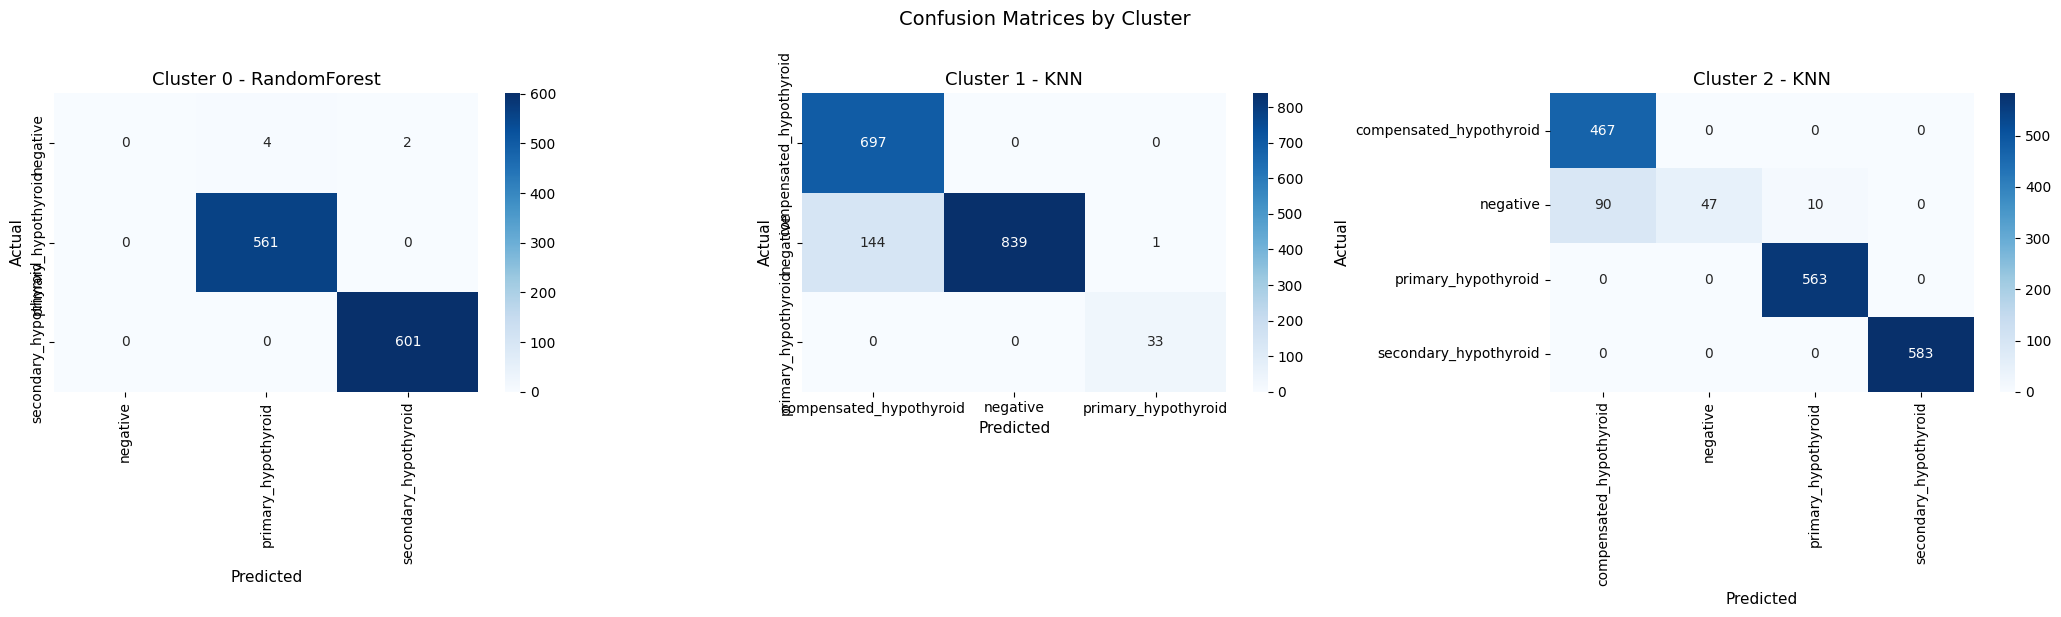

In [32]:
n_clusters = len(cluster_results)
fig, axes = plt.subplots(1, n_clusters, figsize=(7 * n_clusters, 6))

if n_clusters == 1:
    axes = [axes]

for idx, (cluster_id, result) in enumerate(cluster_results.items()):
    ax = axes[idx]
    y_test = result['y_test']
    y_pred = result['best_pred']

    cm = confusion_matrix(y_test, y_pred)
    labels = [str(label_encoder.classes_[i]) for i in sorted(y_test.unique())]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
                yticklabels=labels, ax=ax)
    ax.set_title(f'Cluster {cluster_id} - {result["best_model_name"]}', fontsize=13)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.suptitle('Confusion Matrices by Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 9.4 Overall Performance (Aggregated Across Clusters)

In [33]:
# Aggregate predictions across all clusters
all_y_test = []
all_y_pred = []

for cluster_id, result in cluster_results.items():
    all_y_test.extend(result['y_test'].tolist())
    all_y_pred.extend(result['best_pred'].tolist())

all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

print("Overall Aggregated Performance (across all clusters):")
print("=" * 55)
print(f"Accuracy : {accuracy_score(all_y_test, all_y_pred):.4f}")
print(f"F1 Score (weighted): {f1_score(all_y_test, all_y_pred, average='weighted'):.4f}")
print()

target_names_all = [str(c) for c in label_encoder.classes_]
print("Classification Report:")
print(classification_report(all_y_test, all_y_pred, target_names=target_names_all))

Overall Aggregated Performance (across all clusters):
Accuracy : 0.9459
F1 Score (weighted): 0.9449

Classification Report:
                         precision    recall  f1-score   support

compensated_hypothyroid       0.83      1.00      0.91      1164
               negative       1.00      0.78      0.88      1137
    primary_hypothyroid       0.99      1.00      0.99      1157
  secondary_hypothyroid       1.00      1.00      1.00      1184

               accuracy                           0.95      4642
              macro avg       0.95      0.94      0.94      4642
           weighted avg       0.95      0.95      0.94      4642



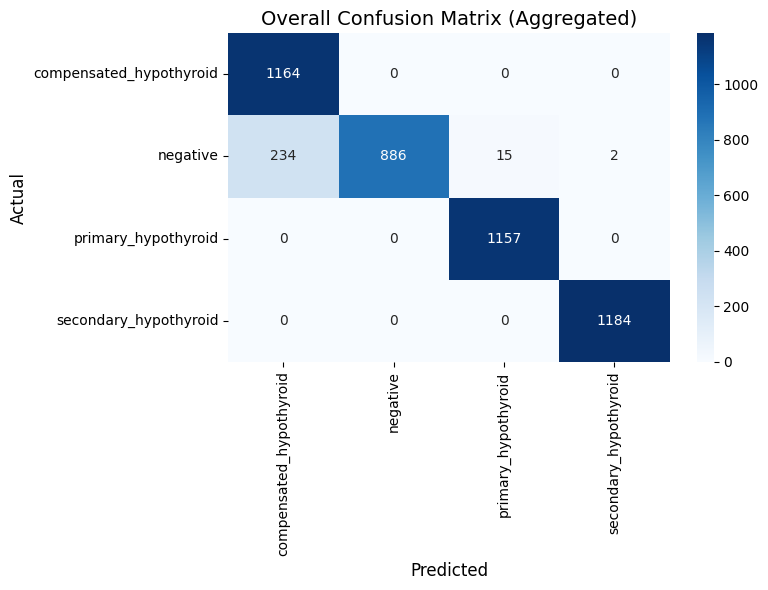

In [34]:
# Overall confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_all = confusion_matrix(all_y_test, all_y_pred)
sns.heatmap(cm_all, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_all, yticklabels=target_names_all, ax=ax)
ax.set_title('Overall Confusion Matrix (Aggregated)', fontsize=14)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

### 9.5 Feature Importance (from Random Forest models)

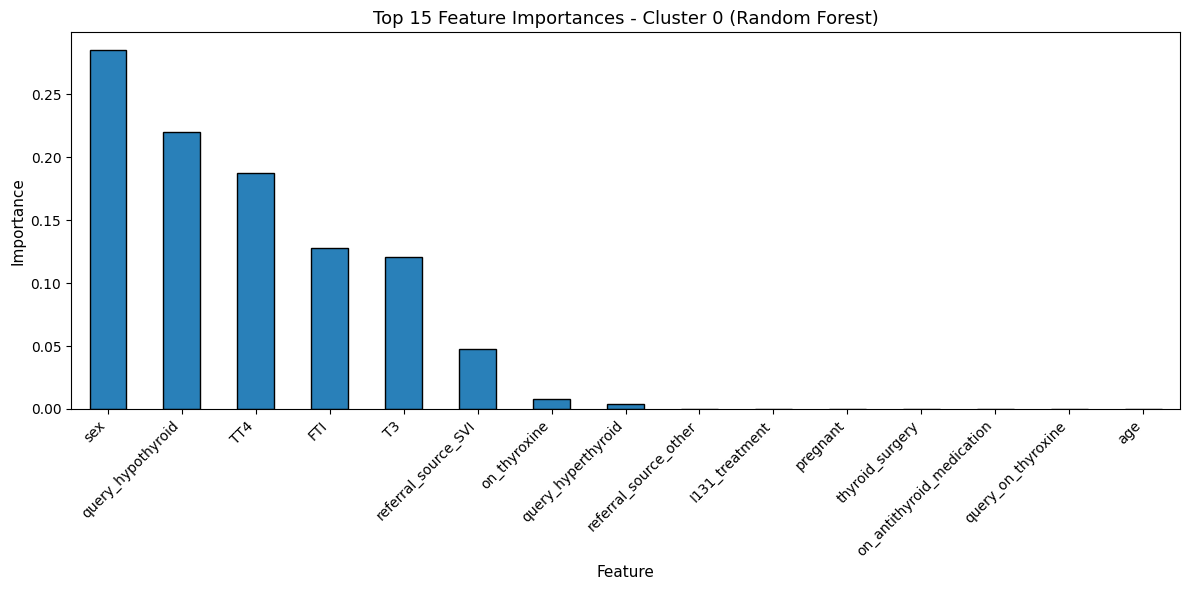

Cluster 1: Best model is KNN (no feature importance available).
Cluster 2: Best model is KNN (no feature importance available).


In [35]:
# Extract feature importance from Random Forest models (if selected as best)
feature_names = X_resampled.columns.tolist()

for cluster_id, model in best_models.items():
    if isinstance(model, RandomForestClassifier):
        importances = model.feature_importances_
        feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

        fig, ax = plt.subplots(figsize=(12, 6))
        feat_imp.head(15).plot(kind='bar', color='#2980b9', edgecolor='black', ax=ax)
        ax.set_title(f'Top 15 Feature Importances - Cluster {cluster_id} (Random Forest)', fontsize=13)
        ax.set_xlabel('Feature', fontsize=11)
        ax.set_ylabel('Importance', fontsize=11)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Cluster {cluster_id}: Best model is KNN (no feature importance available).")

## 10. Conclusion

### 10.1 Summary

This notebook implemented a complete machine learning pipeline for thyroid disease detection:

1. **Data Exploration**: The dataset contains 3772 records with 30 features. The target variable has three classes (negative, compensated_hypothyroid, primary_hypothyroid) with significant class imbalance.

2. **Preprocessing**: Invalid entries marked as '?' were replaced with NaN. Irrelevant measured-flag columns and TBG/TSH were dropped. Categorical features were encoded using label encoding and one-hot encoding. Missing values were imputed using KNN Imputer with k=3.

3. **Class Imbalance Handling**: Random Over Sampling was applied to balance the class distribution before training.

4. **Clustering-Based Modeling**: KMeans clustering was applied to segment the data into subgroups. For each cluster, both Random Forest and KNN classifiers were trained with hyperparameter tuning via GridSearchCV. The best model for each cluster was selected based on ROC-AUC score.

5. **Evaluation**: The models demonstrated strong performance on the test sets across all clusters. The clustering-based approach allows specialized models to handle different data subgroups, potentially capturing patterns that a single global model might miss.

### 10.2 Key Findings

- The dataset is highly imbalanced, with the "negative" class comprising the vast majority of records.
- Lab values such as T3, TT4, T4U, and FTI show distinct distributions across the three thyroid conditions, confirming their diagnostic relevance.
- The clustering approach segments the data meaningfully, and per-cluster model training yields strong classification performance.
- Random Forest and KNN both perform well, with the best model varying by cluster characteristics.

### 10.3 Recommendations for Production Deployment

- Implement robust data validation pipelines (as in the original project) to handle incoming batch files.
- Periodically retrain models as new patient data becomes available.
- Monitor model performance in production using metrics dashboards and set alerting thresholds for accuracy degradation.
- Consider adding additional models such as XGBoost or Gradient Boosting for comparison in future iterations.